In [1]:
import numpy as np
import sys
import importlib

# Force reload to pick up any fixes in Tornado_github.py
if 'Tornado_github' in sys.modules:
    importlib.reload(sys.modules['Tornado_github'])
from Tornado_github import tornado_git

data_sst     = np.load('SST_EOFs_1995_2017_based.npz')
data_tornado = np.load('github_demo.npz')

print("=== SST keys ===")
for key in data_sst.files:
    print(f"  {key}: shape={data_sst[key].shape}, dtype={data_sst[key].dtype}")

print("\n=== Tornado keys ===")
for key in data_tornado.files:
    print(f"  {key}: shape={data_tornado[key].shape}, dtype={data_tornado[key].dtype}")

pcs_obs_sst = data_sst['pcs_obs_sst'].mean(axis=1)
EOFs        = data_sst['EOF']
tornado     = data_tornado['tornado_month']

# Load all lat/lon arrays — we'll pick the right ones for the 1403 grid points
tornado_lat_full = data_tornado['lat']
tornado_lon_full = data_tornado['lon']

print(f"\ntornado shape     : {tornado.shape}")
print(f"lat/lon shape     : {tornado_lat_full.shape} / {tornado_lon_full.shape}")

tornado_model = tornado_git(tornado_data=tornado,
                            predictor=np.reshape(pcs_obs_sst, [20, 12, 30*12]),
                            init_year=1992)
print("tornado_git instance created successfully.")


=== SST keys ===
  pcs_obs_sst: shape=(20, 15, 12, 30, 12), dtype=float64
  EOF: shape=(20, 360, 576), dtype=float64
  variance: shape=(20,), dtype=float64

=== Tornado keys ===
  tornado_month: shape=(30, 1403), dtype=float64
  lat: shape=(23, 61), dtype=float64
  lon: shape=(23, 61), dtype=float64

tornado shape     : (30, 1403)
lat/lon shape     : (23, 61) / (23, 61)
tornado_git instance created successfully.


In [2]:
# Leave-one-out Corss Validation
# ── Run the forecast and retrieve predict & coef ──────────────────────────────
predict, coef = tornado_model._forecast()

# predict : (n_modes, 12, 12, n_years, n_tor_months)
#            mode    init pred  year    target
# coef    : (12, 12, n_years, n_modes, n_tor_months)
print(f"predict shape : {predict.shape}")
print(f"coef shape    : {coef.shape}")


working on mode = 1
working on mode = 2
working on mode = 3
working on mode = 4
working on mode = 5
working on mode = 6
working on mode = 7
working on mode = 8
working on mode = 9
working on mode = 10
working on mode = 11
working on mode = 12
working on mode = 13
working on mode = 14
working on mode = 15
working on mode = 16
working on mode = 17
working on mode = 18
working on mode = 19
working on mode = 20
predict shape : (20, 12, 12, 30, 1403)
coef shape    : (12, 12, 30, 20, 1403)


In [11]:
tornado_model.tornado.shape

(30, 1403)

Randomly selected year : 1994  (index 2)
SST PC vector shape    : (20,)
SST PCs (first 5)      : [ 0.5525  1.3528 -1.413   0.9409 -1.611 ]

Forecast — mean=0.9543,  min=0.0000,  max=1.0000
Observed — mean=0.9666,  min=0.1333,  max=1.0000
  Both in original ECDF percentile space — fair comparison ✓  |  r = 0.936


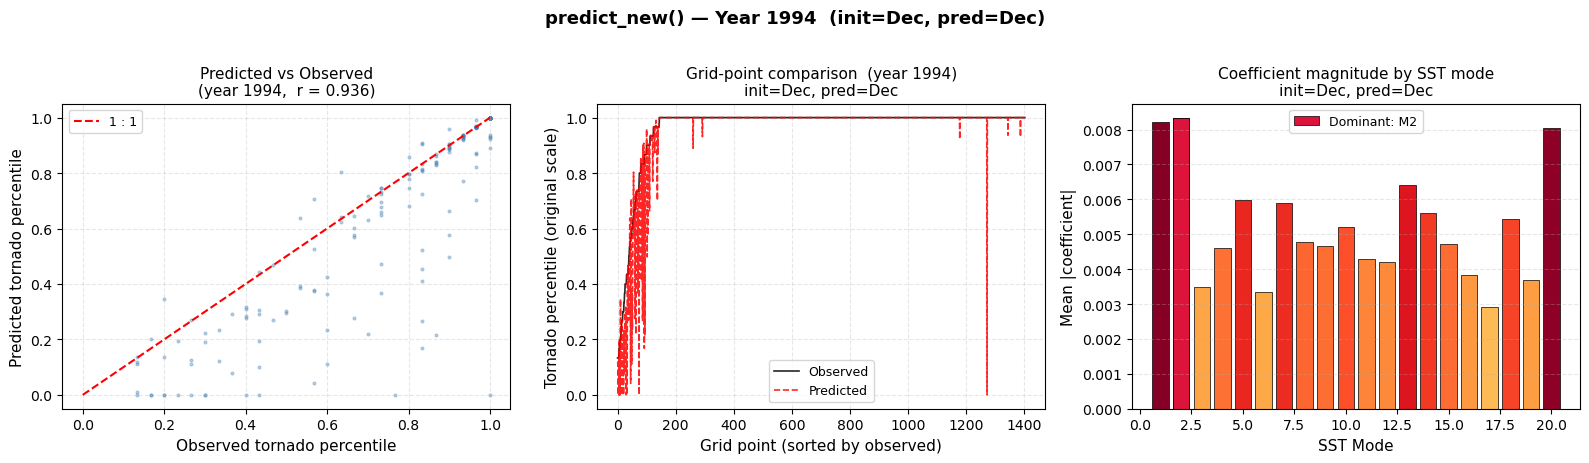

In [14]:
import importlib, pandas as pd
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import pearsonr as _pr
import Tornado_github
importlib.reload(Tornado_github)
from Tornado_github import tornado_git


# Rebind existing instance to the reloaded class
tornado_model.__class__ = tornado_git

# ── Preparing the observation ground Truth ────────────────────────────────────
# ── Recompute ECDF percentile & tornado_percentile_min from raw data ──────────
tor_arr     = tornado_model.tornado      # (n_years, n_grid-point) — reshaped by _forecast()
n_tor       = tor_arr.shape[1]
tor_pct_raw = np.zeros_like(tor_arr, dtype=float)

# -- Calculate point-wise ECDF
for i in range(n_tor):
    ecdf = ECDF(tor_arr[:, i])
    tor_pct_raw[:, i] = ecdf(tor_arr[:, i])

tor_pct_min  = tor_pct_raw.min(axis=0)            # (n_grid-point,) 
tor_pct      = tor_pct_raw - tor_pct_min          # min-removed  (matches _forecast training)
tornado_model.tornado_percentile_min = tor_pct_min

# Observed in original ECDF scale (min added back)
obs_full = tor_pct + tor_pct_min                  # == tor_pct_raw




# ── From here below is the forecast steps ──────────────────────────────────────
# ── Best-skill combination (init=Jul, pred=Jun) ──────────────────────────────── (user can choose their own model)
INIT_MONTH   = 12    # July
PRED_MONTH   = 12    # June
months_label = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

# ── Locate SST PC positions for PRED_MONTH across all years ─────────────────── (the following 3 blocks are preparing user-defined inputs and make forecast)
n_years_data   = tor_arr.shape[0]
dates_1M       = pd.date_range(
    str(tornado_model.init_year) + f'-{INIT_MONTH:02d}',
    periods=n_years_data * 12, freq='1ME'
)
predictor_posi = np.where(dates_1M.month == PRED_MONTH)[0]

# ── Randomly select one year as our target tornado year (seed=42 → year 1994) ──
rng      = np.random.default_rng(seed=42)
rand_idx = int(rng.integers(0, len(predictor_posi)))
rand_yr  = tornado_model.init_year + rand_idx
print(f"Randomly selected year : {rand_yr}  (index {rand_idx})")

sst_pcs_new = tornado_model.predictor[:, INIT_MONTH - 1, predictor_posi[rand_idx]]
print(f"SST PC vector shape    : {sst_pcs_new.shape}")
print(f"SST PCs (first 5)      : {sst_pcs_new[:5].round(4)}")

# ── Call predict_new() ─────────────────────────────────────────────────────────
forecast, coef_used = tornado_model.predict_new(
    sst_pcs=sst_pcs_new, init_month=INIT_MONTH,
    pred_month=PRED_MONTH, coef=coef, n_modes=20
)
obs_yr  = obs_full[rand_idx, :]
r_demo, _ = _pr(obs_yr, forecast)

print(f"\nForecast — mean={forecast.mean():.4f},  min={forecast.min():.4f},  max={forecast.max():.4f}")
print(f"Observed — mean={obs_yr.mean():.4f},  min={obs_yr.min():.4f},  max={obs_yr.max():.4f}")
print(f"  Both in original ECDF percentile space — fair comparison ✓  |  r = {r_demo:.3f}")

# ── Diagnostic plots ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.scatter(obs_yr, forecast, s=4, alpha=0.35, color='steelblue')
lims = [min(obs_yr.min(), forecast.min()), max(obs_yr.max(), forecast.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='1 : 1')
ax.set_xlabel('Observed tornado percentile', fontsize=11)
ax.set_ylabel('Predicted tornado percentile', fontsize=11)
ax.set_title(f'Predicted vs Observed\n(year {rand_yr},  r = {r_demo:.3f})', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3, linestyle='--')

sort_idx = np.argsort(obs_yr)
x_pts    = np.arange(len(sort_idx))
ax2 = axes[1]
ax2.plot(x_pts, obs_yr[sort_idx],   'k-',  lw=1.2, label='Observed',  alpha=0.85)
ax2.plot(x_pts, forecast[sort_idx], 'r--', lw=1.2, label='Predicted', alpha=0.85)
ax2.set_xlabel('Grid point (sorted by observed)', fontsize=11)
ax2.set_ylabel('Tornado percentile (original scale)', fontsize=11)
ax2.set_title(f'Grid-point comparison  (year {rand_yr})\n'
              f'init={months_label[INIT_MONTH-1]}, pred={months_label[PRED_MONTH-1]}', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3, linestyle='--')

ax3 = axes[2]
mode_imp = np.abs(coef_used).mean(axis=1)
bars_col = plt.cm.YlOrRd(mode_imp / mode_imp.max())
ax3.bar(range(1, len(mode_imp)+1), mode_imp, color=bars_col, edgecolor='k', linewidth=0.5)
dominant = int(np.argmax(mode_imp)) + 1
ax3.bar(dominant, mode_imp[dominant-1], color='crimson', edgecolor='k',
        linewidth=0.5, label=f'Dominant: M{dominant}')
ax3.set_xlabel('SST Mode', fontsize=11); ax3.set_ylabel('Mean |coefficient|', fontsize=11)
ax3.set_title(f'Coefficient magnitude by SST mode\n'
              f'init={months_label[INIT_MONTH-1]}, pred={months_label[PRED_MONTH-1]}', fontsize=11)
ax3.grid(axis='y', alpha=0.3, linestyle='--'); ax3.legend(fontsize=9)

plt.suptitle(f'predict_new() — Year {rand_yr}  '
             f'(init={months_label[INIT_MONTH-1]}, pred={months_label[PRED_MONTH-1]})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tornado_forecast_new_year_demo.png', dpi=150, bbox_inches='tight')
plt.show()


Activity threshold : 0.1333  (113 grid points kept)
Forecast anomaly — mean=-0.048, min=-0.500, max=0.407
Observed anomaly — mean=0.101, min=-0.367, max=0.500


/Users/Shared/miniconda3/envs/claude_code/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/Shared/miniconda3/envs/claude_code/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/Shared/miniconda3/envs/claude_code/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/Shared/miniconda3/envs/claude_code/lib/python3.14/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/Shared/miniconda3/envs/claude_code/lib/python3.14/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/Shared/miniconda3/envs/claude_code/lib/python3.14/site-packages/shapely/predicates.py:

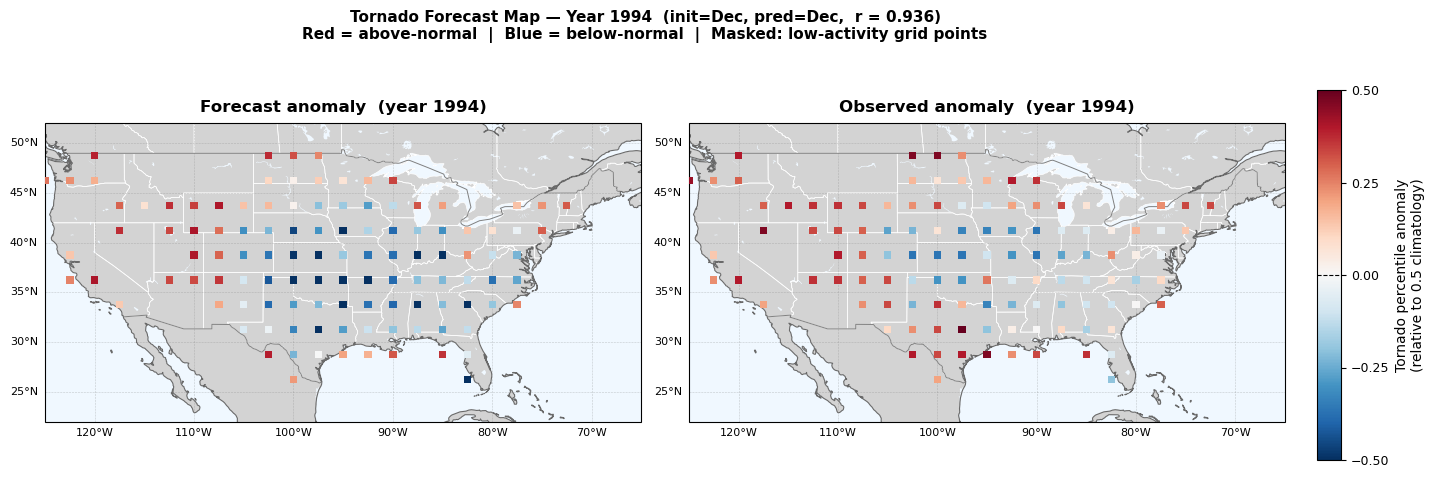

In [15]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import warnings

# ── Flatten (23,61) lat/lon grids → 1403 points ───────────────────────────────
tor_lat = data_tornado['lat'].ravel()    # (1403,)
tor_lon = data_tornado['lon'].ravel()    # (1403,)

# ── Activity mask: raw climatological mean tornado count ──────────────────────
tor_raw_mean = data_tornado['tornado_month'].mean(axis=0)
act_thresh   = np.percentile(tor_raw_mean[tor_raw_mean > 0], 25)
active       = tor_raw_mean >= act_thresh
print(f"Activity threshold : {act_thresh:.4f}  ({active.sum()} grid points kept)")

# ── Subtract 0.5 for anomaly (forecast already clipped to [0,1] by predict_new) ──
fore_anom = forecast[active] - 0.5
obs_anom  = obs_yr[active]   - 0.5

print(f"Forecast anomaly — mean={fore_anom.mean():.3f}, "
      f"min={fore_anom.min():.3f}, max={fore_anom.max():.3f}")
print(f"Observed anomaly — mean={obs_anom.mean():.3f}, "
      f"min={obs_anom.min():.3f}, max={obs_anom.max():.3f}")

# ── Diverging colormap, fixed symmetric range ─────────────────────────────────
cmap   = plt.cm.RdBu_r
absmax = 0.5    # percentile ∈ [0,1] → anomaly ∈ [-0.5, 0.5]
norm   = mcolors.TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)

# ── Continental US extent ─────────────────────────────────────────────────────
proj   = ccrs.PlateCarree()
extent = [-125, -65, 22, 52]

fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                         subplot_kw={'projection': proj})

titles = [f'Forecast anomaly  (year {rand_yr})', f'Observed anomaly  (year {rand_yr})']
anoms  = [fore_anom, obs_anom]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for ax, title, anom in zip(axes, titles, anoms):
        ax.set_extent(extent, crs=proj)
        ax.add_feature(cfeature.LAND,      facecolor='lightgrey', zorder=0)
        ax.add_feature(cfeature.OCEAN,     facecolor='aliceblue', zorder=0)
        ax.add_feature(cfeature.LAKES,     facecolor='aliceblue', zorder=0)
        ax.add_feature(cfeature.STATES,    linewidth=0.5, edgecolor='white',   zorder=1)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.7, edgecolor='grey',    zorder=1)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='dimgrey', zorder=2)

        ax.scatter(tor_lon[active], tor_lat[active],
                   c=anom, cmap=cmap, norm=norm,
                   s=28, marker='s', transform=proj, zorder=3,
                   linewidths=0)

        gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                          color='grey', alpha=0.4, linestyle='--')
        gl.top_labels = False; gl.right_labels = False
        gl.xlabel_style = {'size': 8}; gl.ylabel_style = {'size': 8}
        ax.set_title(title, fontsize=12, fontweight='bold', pad=8)

# ── Shared colour bar ─────────────────────────────────────────────────────────
cbar_ax = fig.add_axes([0.92, 0.12, 0.015, 0.74])
cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
cb.set_label('Tornado percentile anomaly\n(relative to 0.5 climatology)', fontsize=10)
cb.set_ticks([-0.5, -0.25, 0, 0.25, 0.5])
cb.ax.tick_params(labelsize=9)
cb.ax.axhline(0, color='k', linewidth=0.8, linestyle='--')

plt.suptitle(
    f'Tornado Forecast Map — Year {rand_yr}  '
    f'(init={months_label[INIT_MONTH-1]}, pred={months_label[PRED_MONTH-1]},  r = {r_demo:.3f})\n'
    f'Red = above-normal  |  Blue = below-normal  |  Masked: low-activity grid points',
    fontsize=11, fontweight='bold', y=1.02
)
plt.subplots_adjust(right=0.90, wspace=0.08)
plt.savefig('tornado_forecast_map.png', dpi=150, bbox_inches='tight')
plt.show()
